# SKALA DS Mini Project — DAY2 Cycle Life Regression

기존 DAY1 결과·작업 폴더·실행 환경을 이어 사용한다. 실제 학습 코드는 같은 폴더의
`day2_regression.py`이며, 이 notebook은 실행된 학습·freeze·외부 평가 기록과 저장된 결과를 설명한다.
원본 Scratch·MAT·DAY1 출력은 보존했다. 새로운 EDA나 Batch3 모델 평가는 수행하지 않는다.

**Task:** 초기 Cycle100 시점의 정보로 제공 `cycle_life` 예측. 공식 Metric은 MAPE (%),
보조는 RMSE (cycles), R². 모델 입력과 레이블·metadata를 명시적으로 구분한다.

**보호된 실행:** 기본값은 저장된 결과 조회다. 완료된 Batch2의 모델 예측을 반복하지 않는다.
Test 완료 후 개발 재실행은 코드에서 차단된다. 새로운 성능처럼 저장된 값을 꾸며 쓰지 않는다.

In [1]:
from pathlib import Path
import json, inspect
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image, Code
from day2_regression import model_and_grid, search, development, final_test
from project_paths import BASE_DIR
ROOT=BASE_DIR
RESULTS=ROOT/'results'
FIGURES=ROOT/'figures'
RUN_DEVELOPMENT=False
RUN_FINAL_TEST=False
audit=json.loads((RESULTS/'day1_audit.json').read_text())
freeze=json.loads((RESULTS/'model_freeze.json').read_text())
receipt=json.loads((RESULTS/'batch2_test_receipt.json').read_text())
assert audit['passed'] and receipt['status']=='completed' and receipt['prediction_calls']==1
print('Stored final test completed at:',receipt['completed_at'])
print('Frozen candidate:',freeze['candidate'])
print('No Batch3 model evaluation:',not freeze['Batch3_evaluated'])

Stored final test completed at: 2026-10-01T14:26:31.372826+09:00
Frozen candidate: B_Expanded__RandomForest
No Batch3 model evaluation: True


## 1. DAY1 최종 검증

Scratch 원본 셀 10·13에는 첫 상세 사이클 empty와 summary 0이 보인다.
원본 셀 33은 여전히 Cycle1–100을 집계하므로, Cycle1 제외를 원본 코드의 처리라고 말하면 안 된다.
현재 DAY1은 Batch1의 placeholder를 제외하고 Batch 공통 구간을 **Cycle2–100, 99개**로 맞췄다.
Batch2·3 Cycle1은 정상이다. 이 선택과 0·비유한값 처리, `std_QD`의 이상값 민감도를 그대로 유지한다.

Raw 재계산은 공통 1,000점 축의 Q100−Q10과 명시적 population variance를 사용했다.
모든 Feature가 저장값과 계산 오차 범위 내에서 일치했다. 수명 결측 10개는 대체하지 않는다.
원본 레이블은 논문의 정제·연속 기록 연결까지 재구성한 레이블과 같다고 확정하지 않았다.

In [2]:
display(pd.read_csv(RESULTS/'day1_cycle1_audit.csv'))
display(pd.read_csv(RESULTS/'day1_audit.csv'))
display(Markdown(f"최대 Feature 재계산 차이: **{max(audit['feature_max_abs_error'].values()):.3g}**. DAY1 결과 변경 없음."))

,batch,raw_cells,cycle1_all_summary_zero,cycle1_Qdlin_empty,missing_target
0,Batch1,46,46,46,0
1,Batch2,47,0,0,8
2,Batch3,46,0,0,2


,check,status,detail
0,Cycle2–100 rationale,PASS_WITH_NOTE,Batch1 Cycle1 has zero summary placeholders an...
1,Delta Q formula,PASS,Q100 minus Q10; aligned 1000-point voltage gri...
2,Eight feature recomputation,PASS,{'log_var_delta_Q': np.float64(4.4408920985006...
3,Missing target exclusion,PASS,"NaN target retained in 139-row master, exclude..."
4,Feature time boundary,PASS,Summary features use Cycle2–100; capacity diff...
5,Preprocessing provenance,PASS_WITH_NOTE,Nonpositive/nonfinite measurements marked miss...
6,External-test limitations,DISCLOSED,Batch2/3 already inspected in DAY1. Batch2 is ...
7,Label and physical identity,DISCLOSED,Provided raw labels retained; not a reconstruc...


최대 Feature 재계산 차이: **1.42e-14**. DAY1 결과 변경 없음.

## 2. 확정한 설계와 Feature Table

Batch별 수명 분포 차이 → Batch Shift 가능성 → Batch1 개발, Batch2 최종 외부 평가.
ΔQ 로그 분산의 일관된 음의 상관 → 확정 Core → 초기 100-cycle Regression.
C-rate 단독 관계의 비일관성 → 충전 설정은 ablation으로만 비교.
기타 후보의 채택은 Batch1 내부 성능으로 결정했다.

**Master 139행 / labeled 129행:** 1 row = 1 원본 배터리 셀 기록.
`batch`, `cell_id`, `source_cell_index`, 정책 문자열, target 여부는 metadata다.
8개 후보 Feature를 원래 DAY1 정의로 유지하고 C1/C2/switch_pct를 별도 후보로 보관했다.
전체 곡선·최종 사이클·기록 길이·정책 평균 수명은 모델 입력에 넣지 않는다.

In [3]:
df=pd.read_csv(RESULTS/'feature_table.csv')
features=audit['expanded']
display(df.groupby('batch').agg(raw_cells=('cell_id','size'),labeled=('target_available','sum')))
display(df[['batch','cell_id']+features+['cycle_life']].head())
schema=json.loads((RESULTS/'feature_schema.json').read_text())
display(Markdown('**최종 모델 입력:** '+', '.join(schema['model_features'])))
assert not set(schema['model_features']).intersection(schema['not_model_inputs']+schema['excluded_future_columns'])

,raw_cells,labeled
batch,,
Batch1,46,46
Batch2,47,39
Batch3,46,44


,batch,cell_id,log_var_delta_Q,mean_QD,std_QD,mean_IR,mean_Tavg,mean_Tmax,mean_chargetime,delta_QD_100_10,cycle_life
0,Batch1,Batch1_C000,-5.014861,1.080597,0.046562,0.016643,31.603747,35.376748,13.384231,0.001375,1190.0
1,Batch1,Batch1_C001,-5.013960,1.081247,0.001191,0.016922,31.330314,34.160655,13.374696,0.000853,1179.0
2,Batch1,Batch1_C002,-4.737000,1.085371,0.001026,0.016769,31.479584,34.544644,13.378886,0.001159,1177.0
3,Batch1,Batch1_C003,-4.442613,1.084949,0.001096,0.016311,29.942199,30.662263,12.053277,0.000442,1226.0
4,Batch1,Batch1_C004,-4.647744,1.082844,0.001095,0.016669,31.448884,34.382516,12.053314,0.000692,1227.0


**최종 모델 입력:** log_var_delta_Q, mean_QD, std_QD, mean_IR, mean_Tavg, mean_Tmax, mean_chargetime, delta_QD_100_10

## 3. Train / Holdout 및 preprocessing

Batch1 46개에서 seed42의 고정 무작위 분할: Train34 / Holdout12.
분할을 바꾸어 성능을 맞추지 않았다. 물리 셀 중복 여부의 확정 식별은 별도 한계로 기록했다.
10개의 outer fold는 Train34 내부 5-fold × 2회다. 각 outer Train 내부 3-fold CV에서만 튜닝한다.
따라서 Train 성능은 fitted training error가 아닌 **nested outer CV 평균**이다.

중앙값 Imputer와 Ridge StandardScaler는 Pipeline 안에서 Train fold에만 fit한다.
target은 고정 `log(y)` 후 예측을 `exp`로 복원한다. MAPE/RMSE/R²는 원래 cycle 단위에서 계산한다.
이는 log 공간 오차를 공식 MAPE로 보고한다는 뜻이 아니다.

In [4]:
split=pd.read_csv(RESULTS/'batch1_split.csv')
display(split.groupby('split').cycle_life.agg(['count','min','max','median']))
display(Code(inspect.getsource(model_and_grid),language='python'))
display(Code(inspect.getsource(search),language='python'))

,count,min,max,median
split,,,,
HoldoutValid,12,616.0,1227.0,874.5
Train,34,534.0,1190.0,849.5


def model_and_grid(family):
    if family == 'Ridge':
        estimator = Ridge()
        grid = {'regressor__model__alpha':[.1,1.,10.,100.]}
    elif family == 'RandomForest':
        estimator = RandomForestRegressor(n_estimators=150,random_state=SEED,n_jobs=1)
        grid = {'regressor__model__max_depth':[3,None],
                'regressor__model__min_samples_leaf':[2,4]}
    else:
        estimator = GradientBoostingRegressor(n_estimators=150,min_samples_leaf=3,random_state=SEED)
        grid = {'regressor__model__max_depth':[1,2],
                'regressor__model__learning_rate':[.03,.1]}
    steps = [('imputer',SimpleImputer(strategy='median',keep_empty_features=True))]
    if family == 'Ridge': steps.append(('scaler',StandardScaler()))
    steps.append(('model',estimator))
    # Fixed, reversible target transform; scoring always uses original cycle units.
    model = TransformedTargetRegressor(regressor=Pipeline(steps),func=np.log,inverse_func=np.exp)
    return model,grid

def search(model,grid,X,y):
    cv = KFold(n_splits=3,shuffle=True,random_state=SEED)
    result = GridSearchCV(model,grid,scoring='neg_mean_absolute_percentage_error',
                          cv=cv,n_jobs=1,refit=True,error_score='raise')
    return result.fit(X,y)

## 4. Feature Set·모델 비교와 선택

- A Core: `log_var_delta_Q` 1개.
- B Expanded: DAY1 초기 Feature 8개.
- C Charging ablation: B + C1/C2/switch_pct, 11개.

Ridge·RandomForest·GradientBoosting 세 모델 가족의 제한된 4개 parameter 조합만 비교했다.
LightGBM/XGBoost를 설치하지 않았다. Holdout에는 각 Train-CV 최적 후보를 한 번 평가했다.
Feature를 추가하거나 파라미터 범위를 다시 바꾸는 Holdout 반복 탐색은 하지 않았다.

**선택 규칙:** 최소 Valid MAPE 우선. 0.5%p 이내이며 CV 평균이 +1%p, SD가 +2%p 이내인
가까운 후보에서는 Feature 수와 모델 단순성을 우선한다. 이 규칙은 Batch2 평가 전에 저장했다.

,feature_set,model,n_features,Train_CV_MAPE_percent,Train_CV_MAPE_SD_pp,Valid_MAPE_percent,Train_Valid_Gap_pp,selected
0,A_Core,Ridge,1,9.8636,1.6767,9.6651,-0.1986,False
1,A_Core,RandomForest,1,9.1526,1.8520,9.2570,0.1044,False
2,A_Core,GradientBoosting,1,9.9310,2.0883,10.2942,0.3631,False
3,B_Expanded,Ridge,8,11.3759,5.4355,10.4346,-0.9413,False
4,B_Expanded,RandomForest,8,9.4981,2.4806,8.5746,-0.9236,True
5,B_Expanded,GradientBoosting,8,9.2007,1.9542,9.3184,0.1177,False
6,C_Charging_ablation,Ridge,11,9.0385,2.3868,9.9678,0.9293,False
7,C_Charging_ablation,RandomForest,11,9.4835,2.5772,8.5567,-0.9268,False
8,C_Charging_ablation,GradientBoosting,11,9.1965,2.3318,9.3857,0.1891,False


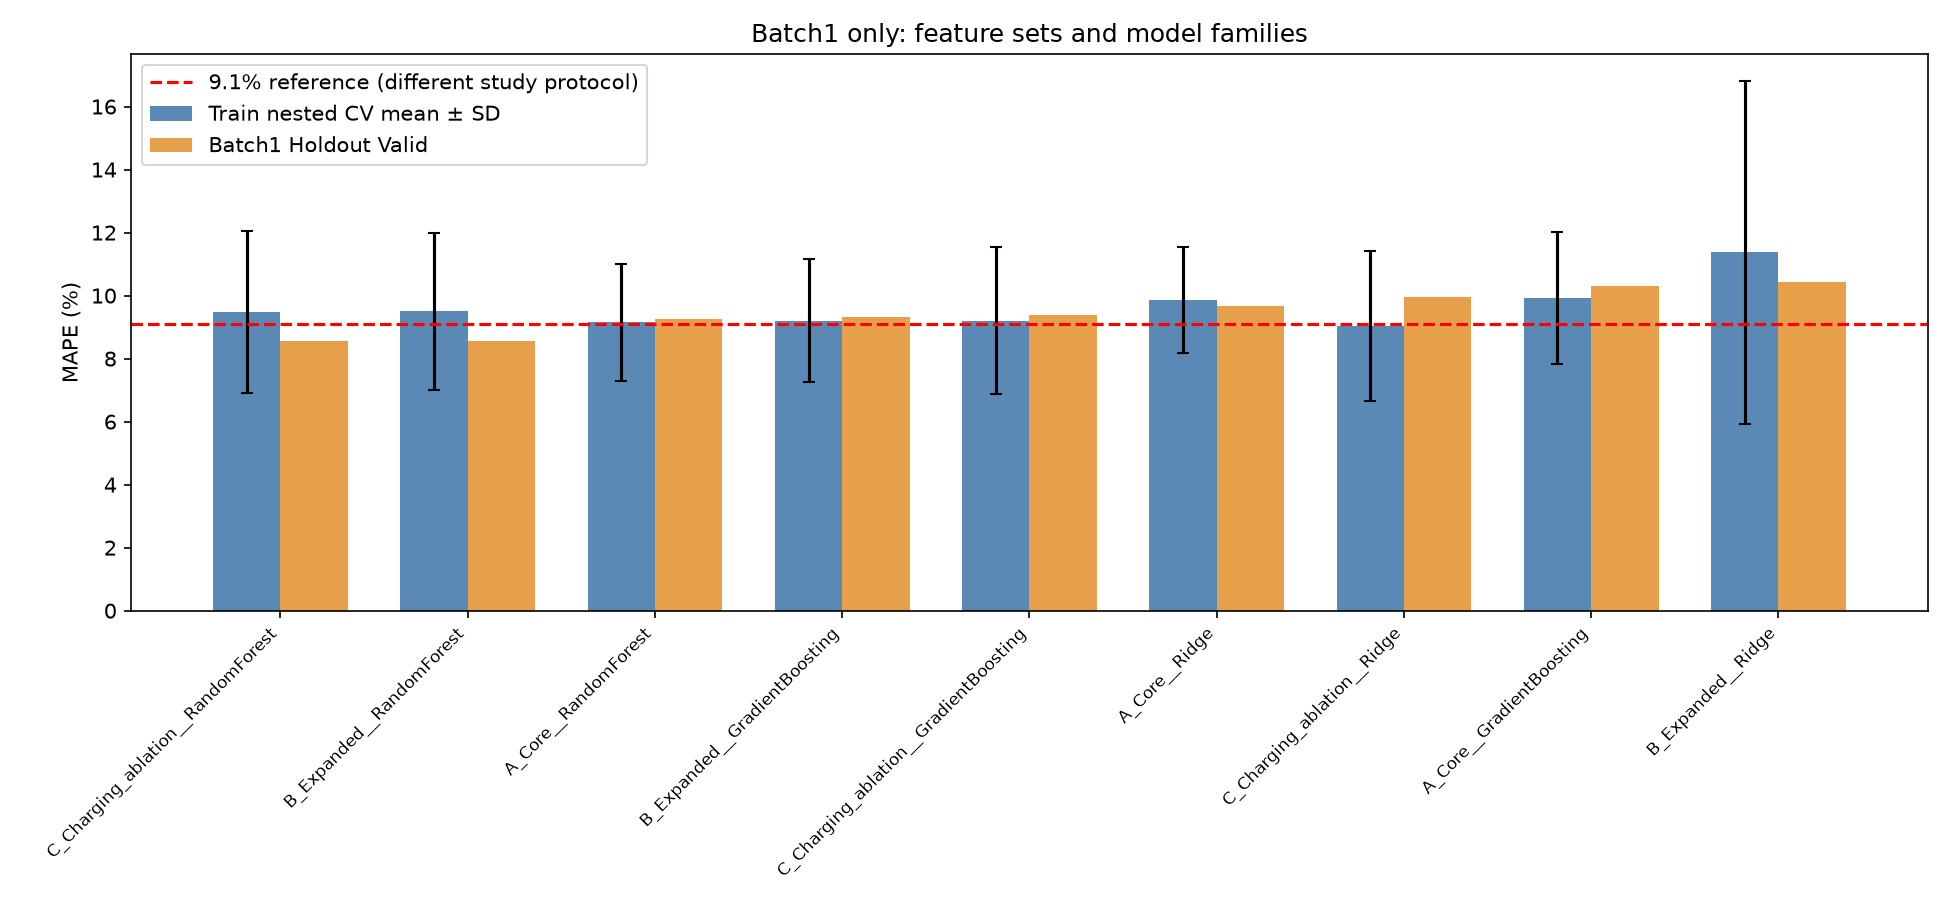

**Freeze 근거:** Chosen before Batch2 evaluation: Valid 8.5746%, nested CV 9.4981% ± 2.4806 pp; 8 features. Near-tie simplicity rule applied within fixed tolerances.

충전 설정 3개 추가 시 Valid MAPE 개선은 **0.0179%p**. 개선이 매우 작아 더 단순한 Expanded 8개를 선택했다.

In [5]:
if RUN_DEVELOPMENT:
    development()  # Test 완료 이후에는 보호 코드가 개발 재실행을 차단한다.
comparison=pd.read_csv(RESULTS/'development_comparison.csv')
display(comparison[['feature_set','model','n_features','Train_CV_MAPE_percent',
    'Train_CV_MAPE_SD_pp','Valid_MAPE_percent','Train_Valid_Gap_pp','selected']].round(4))
display(Image(filename=str(FIGURES/'day2_development_comparison.png')))
display(Markdown('**Freeze 근거:** '+freeze['selection_reason']))
b=comparison[(comparison.feature_set=='B_Expanded')&(comparison.model=='RandomForest')].iloc[0]
c=comparison[(comparison.feature_set=='C_Charging_ablation')&(comparison.model=='RandomForest')].iloc[0]
display(Markdown(f"충전 설정 3개 추가 시 Valid MAPE 개선은 **{b.Valid_MAPE_percent-c.Valid_MAPE_percent:.4f}%p**. "
    '개선이 매우 작아 더 단순한 Expanded 8개를 선택했다.'))

## 5. Freeze 후 Batch2 one-shot Test

Feature·hyperparameter·전처리·fitted model·Train/Valid ID·해시를 freeze했다.
최종 모델은 Train34에만 fit했다. Holdout에 재적합하지 않아 Valid와 Test가 동일 fitted model을 평가한다.
Batch2의 유효 수명 39개에 predict 한 번을 수행했으며 Batch3에는 predict하지 않았다.

이미 Batch2는 DAY1에서 관찰했으므로 완전한 untouched blind test라고 주장하지 않는다.
모델 freeze 이후의 단 한 번 외부 평가로 보고한다. Test 결과를 보고 모델을 변경하지 않았다.
9.1%는 사용자 지정 논문 참고 목표이고 이번 데이터 정제·분할이 논문과 같다고 확인한 것은 아니다.

,split,n,MAPE_percent,RMSE_cycles,R2
0,Train (Batch1 nested CV),34,9.4981,90.8892,0.2733
1,Valid (Batch1 Holdout),12,8.5746,100.0332,0.7667
2,Test (Batch2),39,32.8275,169.8455,0.4004


,gap,formula,value_pp
0,Train–Valid,Valid − Train CV,-0.9236
1,Valid–Test,Test − Valid,24.2529
2,Target–Test,Test − 9.1,23.7275


논문 참고 Target: **9.1%**. 실제 Test MAPE **32.8275%**로 목표에 도달하지 못했다. Gap의 양수는 뒤의 평가 오차가 더 큼을 뜻한다. 음수 Train–Valid Gap은 과적합이 없다는 증명이 아니다.

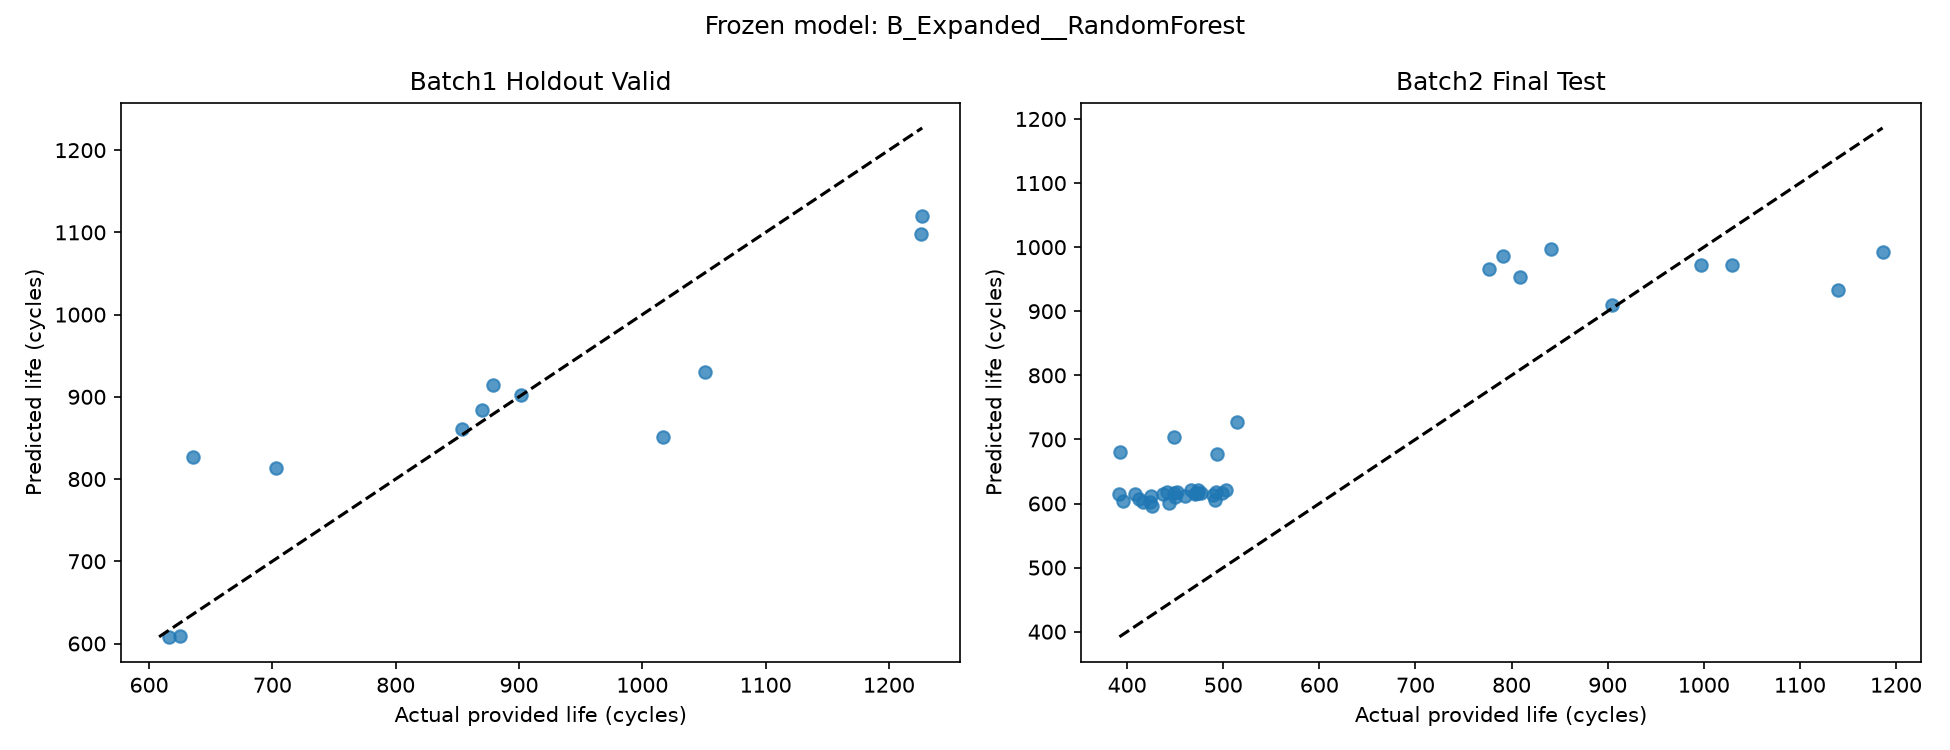

In [6]:
if RUN_FINAL_TEST:
    final_test()  # 완료된 receipt가 있으면 기존 표만 반환하며 새 prediction을 수행하지 않는다.
performance=pd.read_csv(RESULTS/'model_performance.csv')
r=performance.iloc[0]
display(pd.DataFrame({'split':['Train (Batch1 nested CV)','Valid (Batch1 Holdout)','Test (Batch2)'],
 'n':[r.Train_n,r.Valid_n,r.Test_n],
 'MAPE_percent':[r.Train_Batch1_CV_MAPE_percent,r.Valid_Batch1_MAPE_percent,r.Test_Batch2_MAPE_percent],
 'RMSE_cycles':[r.Train_CV_RMSE_cycles,r.Valid_RMSE_cycles,r.Test_RMSE_cycles],
 'R2':[r.Train_CV_R2,r.Valid_R2,r.Test_R2]}).round(4))
display(pd.DataFrame({'gap':['Train–Valid','Valid–Test','Target–Test'],
 'formula':['Valid − Train CV','Test − Valid','Test − 9.1'],
 'value_pp':[r.Train_Valid_Gap_pp,r.Valid_Test_Gap_pp,r.Target_Test_Gap_pp]}).round(4))
display(Markdown(f"논문 참고 Target: **9.1%**. 실제 Test MAPE **{r.Test_Batch2_MAPE_percent:.4f}%**로 목표에 도달하지 못했다. "
    'Gap의 양수는 뒤의 평가 오차가 더 큼을 뜻한다. 음수 Train–Valid Gap은 과적합이 없다는 증명이 아니다.'))
display(Image(filename=str(FIGURES/'day2_valid_test_predictions.png')))

## 6. Cell Error Analysis — 저장된 예측만 사용

오차 정의: signed error = predicted − actual; APE = |predicted−actual|/actual × 100.
Feature의 Train 범위 밖 여부와 결측, 정책의 Train 관측 여부를 사후 진단으로 표시한다.
이 표는 이미 끝난 평가를 설명하는 용도다. 모델 선택·추가 튜닝에는 사용하지 않는다.

,cell_id,cycle_life,predicted_cycle_life,signed_error_cycles,APE_percent,outside_train_range_features,missing_model_features
0,Batch2_C006,393.0,679.7679,286.7679,72.9689,mean_Tmax,NaN
1,Batch2_C018,449.0,704.3892,255.3892,56.8796,delta_QD_100_10,NaN
2,Batch2_C019,392.0,614.0527,222.0527,56.6461,log_var_delta_Q,NaN
3,Batch2_C015,396.0,604.4488,208.4488,52.6386,delta_QD_100_10,NaN
4,Batch2_C021,408.0,614.4122,206.4122,50.5912,"log_var_delta_Q,mean_QD,mean_Tmax",NaN
5,Batch2_C030,412.0,607.4322,195.4322,47.4350,"log_var_delta_Q,mean_chargetime",NaN
6,Batch2_C005,416.0,601.7468,185.7468,44.6507,"log_var_delta_Q,delta_QD_100_10",NaN
7,Batch2_C031,425.0,611.1738,186.1738,43.8056,mean_QD,NaN
8,Batch2_C002,424.0,601.8795,177.8795,41.9527,NaN,NaN
9,Batch2_C024,514.0,727.0529,213.0529,41.4500,"mean_Tmax,delta_QD_100_10",NaN


,feature,Train_min,Train_max,Test_min,Test_max,Test_below_Train_min,Test_above_Train_max,Test_missing
0,log_var_delta_Q,-5.014861,-3.350338,-4.448585,-3.085882,0,11,0
1,mean_QD,1.060084,1.097068,1.067132,1.111178,0,20,0
2,std_QD,0.000581,0.182521,0.001291,0.015028,0,0,0
3,mean_IR,0.015090,0.018005,0.014791,0.017701,4,0,6
4,mean_Tavg,30.375397,33.894970,29.881509,35.667891,2,5,0
5,mean_Tmax,30.709141,37.756140,31.012201,39.797135,0,8,0
6,mean_chargetime,8.987271,15.075768,10.035778,49.879507,0,10,0
7,delta_QD_100_10,-0.014476,0.002100,-0.022705,0.010472,1,14,0


,feature,training_feature_importance
0,log_var_delta_Q,0.851185
1,mean_QD,0.052857
2,std_QD,0.009692
3,mean_IR,0.007756
4,mean_Tavg,0.031626
5,mean_Tmax,0.016030
6,mean_chargetime,0.025573
7,delta_QD_100_10,0.005281


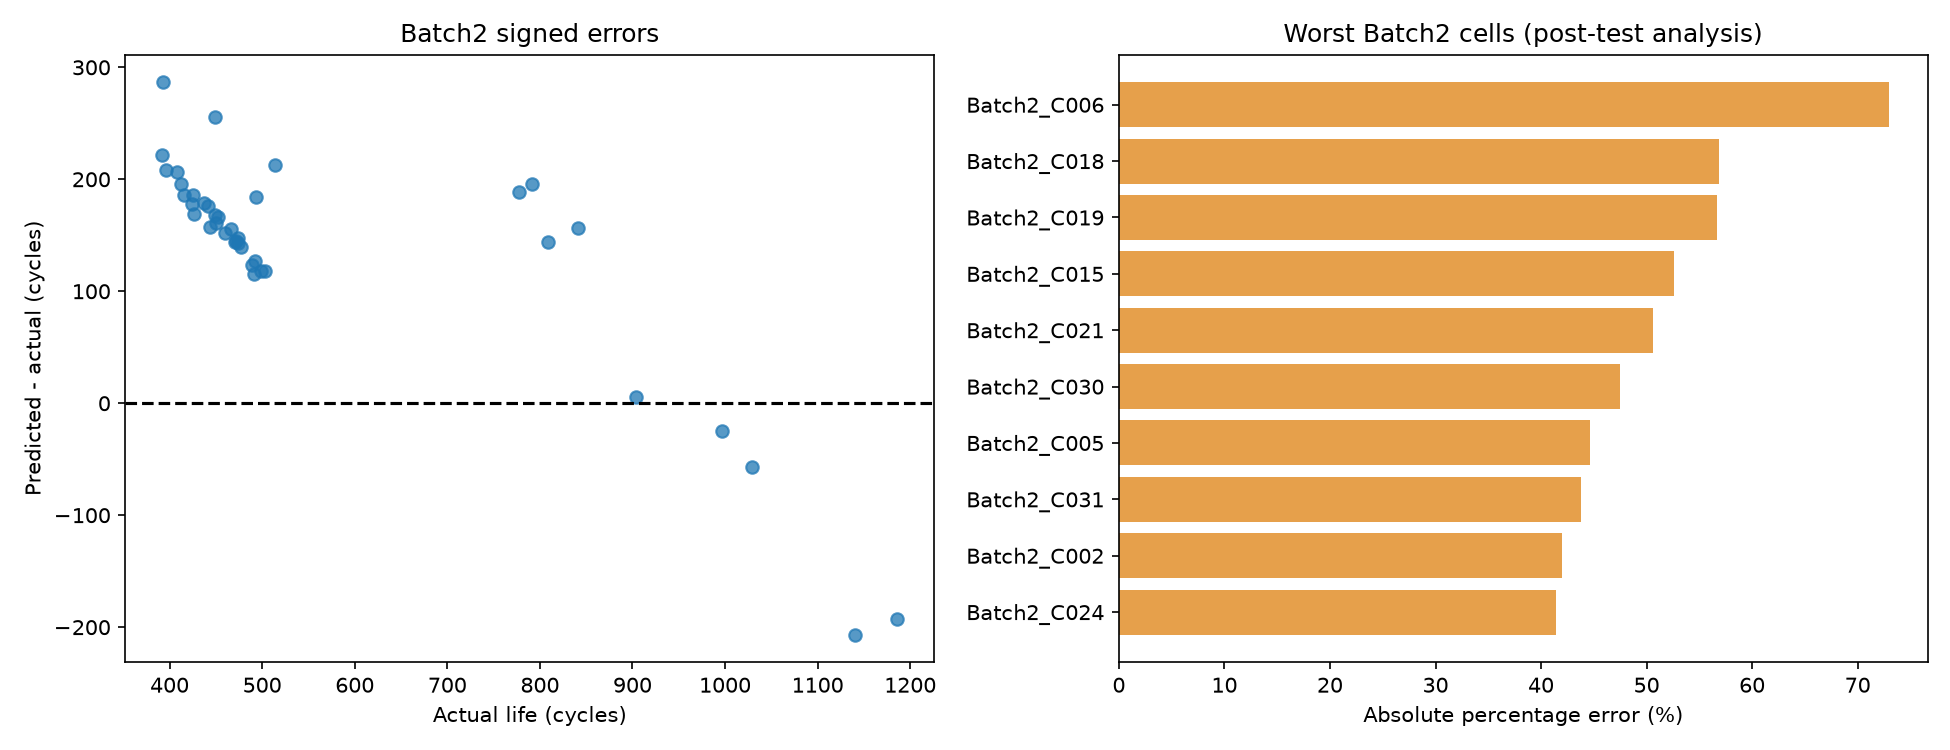

Batch2 **35/39개**를 과대예측했다. Train target 범위는 534–1190이고 Test 30개가 Train 최솟값보다 짧다. 실제 예측 범위는 595.33–997.71 cycles다. RandomForest의 학습 target 범위 밖 외삽 제한과 이번 짧은 수명 과대예측이 일치한다. 입력 범위 차이도 관측되지만 모든 오류의 인과적 원인을 확정한 것은 아니다.

In [7]:
error=pd.read_csv(RESULTS/'cell_error_analysis.csv')
display(error[['cell_id','cycle_life','predicted_cycle_life','signed_error_cycles','APE_percent',
    'outside_train_range_features','missing_model_features']].head(10).round(4))
diagnostics=json.loads((RESULTS/'post_test_diagnostics.json').read_text())
display(pd.read_csv(RESULTS/'post_test_feature_ranges.csv').round(6))
display(pd.read_csv(RESULTS/'model_explanation.csv').round(6))
display(Image(filename=str(FIGURES/'day2_error_analysis.png')))
display(Markdown(f"Batch2 **{diagnostics['overprediction_n']}/{diagnostics['test_n']}개**를 과대예측했다. "
    f"Train target 범위는 {diagnostics['train_target_min']:.0f}–{diagnostics['train_target_max']:.0f}이고 "
    f"Test {diagnostics['test_target_below_train_min_n']}개가 Train 최솟값보다 짧다. "
    f"실제 예측 범위는 {diagnostics['test_prediction_min']:.2f}–{diagnostics['test_prediction_max']:.2f} cycles다. "
    'RandomForest의 학습 target 범위 밖 외삽 제한과 이번 짧은 수명 과대예측이 일치한다. '
    '입력 범위 차이도 관측되지만 모든 오류의 인과적 원인을 확정한 것은 아니다.'))

## 7. ESS/PdM 해석과 평가 한계

수명 과대예측은 점검·교체 시기를 늦추는 위험, 과소예측은 조기 점검·교체 비용과 연결될 수 있다.
이번 외부 평가에서 과대예측이 다수이므로 평균 MAPE뿐 아니라 signed error와 큰 오차 셀을 봐야 한다.
실험 셀의 cycle_life Regression을 검증한 것이며, 현장 ESS의 RUL·calendar aging·시스템 고장을
검증한 것은 아니다. 운영 안전 마진이나 실제 교체 임계값은 여기서 확정하지 않는다.

Train34·Holdout12의 작은 개발 표본, Feature 분포 차이, 물리 셀 식별 한계, 제공 레이블 정제 차이를
함께 기록한다. Outer CV는 내부 hyperparameter 튜닝을 분리하지만 가족·Feature Set을 여러 후보 중
최종 선택한 효과까지 제거하는 전체 개발 절차의 unbiased 추정이라고 주장하지 않는다.
Fold SD는 신뢰구간이 아니다. 높은 상관과 큰 impurity importance도 외부 일반화 성능을 보장하지 않는다.

## 8. Consistency Audit

DAY1의 Feature 정의와 모델 입력, 분할·전처리 fit 범위, freeze→Test 순서, Batch3 미평가를 검증한다.
실행·성능·의사결정은 CSV/JSON으로 남긴다. 원본·DAY1은 해시로 보존 여부를 확인했다.

In [8]:
display(pd.read_csv(RESULTS/'decision_log.csv'))
consistency=pd.read_csv(RESULTS/'consistency_audit.csv')
display(consistency)
assert consistency.passed.all()
assert json.loads((RESULTS/'batch2_test_receipt.json').read_text())['prediction_calls']==1
print('Audit passed. Outputs are actual saved results. Batch2 was not predicted again; Batch3 was not evaluated.')

,step,decision,reason
0,1,Retain DAY1 definitions,Raw recomputation matches saved output; common...
1,2,Regression / log target / MAPE,Positive lifetime and relative-error objective...
2,3,"Fixed Batch1 Train34/Valid12 split, seed42",Independent Holdout; no split shopping or Batc...
3,4,Three families and three predefined feature sets,"Core interpretability, Expanded comparison, ch..."
4,5,Nested Train CV,Hyperparameters chosen within inner folds; out...
5,6,B_Expanded__RandomForest,Chosen before Batch2 evaluation: Valid 8.5746%...
6,7,Freeze fitted Train34 model before Test,Same fitted model for Holdout and external Tes...
7,8,One-shot external test complete,Batch2 MAPE=32.8275%; no subsequent tuning or ...


,item,passed,evidence
0,DAY1 artifacts and Scratch unchanged,True,SHA256 checks against pre-development snapshot
1,Early 100-cycle boundary,True,Raw audit confirms Cycle2–100 + Q10/Q100 only
2,One row per recorded battery cell,True,"139 raw records, 129 target-available"
3,Batch1-only model development,True,Fixed split; all CV/tuning/selection confined ...
4,Preprocessing fit inside training folds,True,"Imputer/scaler in Pipeline, inner tuning insid..."
5,Train performance is CV mean,True,"10 nested outer-fold metrics, no fitted traini..."
6,Holdout not used for fitting,True,Artifact fit on Train34; Holdout12 used for fi...
7,Core delta feature retained,True,B_Expanded
8,Batch2 once after freeze,True,b6a3d73b8db6b99d36d96fbfdbeab3cbf3ea0fc4f6b509...
9,Batch3 model evaluation absent,True,No Batch3 prediction/metrics code path


Audit passed. Outputs are actual saved results. Batch2 was not predicted again; Batch3 was not evaluated.
